# 02 - Predictive GNN: Training and Evaluation

This notebook trains the EGFR GNN regressor (lightweight demo) and generates a parity plot (True vs Predicted pIC50). If real processed graphs exist in `data/processed`, they will be used; otherwise the notebook runs with synthetic data for demonstration.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn torch-geometric tensorboard biopython 

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports and setup
# Keep warning noise out of the notebook so the training signal is easier to read.
import sys
import importlib
import warnings

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='.*IProgress not found.*')

from pathlib import Path
import numpy as np, pandas as pd
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
import core.gnn_architecture as gnn_architecture
importlib.reload(gnn_architecture)
from core.gnn_architecture import EGFR_GNN_Regressor

OUT = ROOT / 'results' / 'figures'
OUT.mkdir(parents=True, exist_ok=True)

# Reload the local model module and choose the best available accelerator for training.
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Environment ready; using device: {device}')

Environment ready; using device: cuda


In [3]:
# Load processed graphs AND real labels from bioactivity CSV
DATA_PROC = ROOT / 'data' / 'processed'
DATA_RAW = ROOT / 'data' / 'raw' / 'bioactivity'


def normalize_edge_index(graph):
    """Ensure PyG edge_index uses shape [2, num_edges]."""
    if hasattr(graph, 'edge_index') and graph.edge_index is not None:
        edge_index = graph.edge_index
        if edge_index.ndim == 2 and edge_index.shape[0] != 2 and edge_index.shape[1] == 2:
            graph.edge_index = edge_index.t().contiguous()
    return graph


# Load graphs
graph_file = DATA_PROC / 'graph_data.pt'
if graph_file.exists():
    graphs = torch.load(str(graph_file), weights_only=False)
    graphs = [normalize_edge_index(graph) for graph in graphs]
    print(f'✓ Loaded {len(graphs)} graphs from {graph_file}')
else:
    print(f'⚠ graph_data.pt not found. Run Notebook 01 first.')
    graphs = []

# Load real pIC50 labels from bioactivity CSV
csv_file = DATA_RAW / 'egfr_full_standardized.csv'
if csv_file.exists() and graphs:
    df = pd.read_csv(csv_file)
    # Get first N labels to match graph count
    y_labels = df['pChEMBL_Value'].values[:len(graphs)]
    print(f'✓ Loaded {len(y_labels)} pIC50 labels from {csv_file.name}')
elif graphs:
    # Fallback: use synthetic labels
    y_labels = np.random.normal(6.5, 1.5, len(graphs))
    print('⚠ Using synthetic pIC50 labels (run Notebook 01 with real data for production)')
else:
    print('ERROR: No graphs available. Cannot proceed.')
    graphs = []
    y_labels = []

print(f'Dataset size: {len(graphs)} graphs, {len(y_labels)} labels')

# 3-Way Split: Train (70%), Validation (15%), Test (15%)
from sklearn.model_selection import train_test_split

if len(graphs) > 0:
    n_total = len(graphs)
    # First split: 70% train, 30% temp (val+test)
    train_idx, temp_idx = train_test_split(np.arange(n_total), test_size=0.3, random_state=42)
    # Second split: 50/50 of temp → 15% val, 15% test
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)
    
    train_graphs = [graphs[i] for i in train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]
    
    y_train = y_labels[train_idx]
    y_val = y_labels[val_idx]
    y_test = y_labels[test_idx]
    
    print(f'\n3-Way Data Split:')
    print(f'  Train: {len(train_graphs)} graphs ({100*len(train_graphs)/n_total:.1f}%)')
    print(f'  Val:   {len(val_graphs)} graphs ({100*len(val_graphs)/n_total:.1f}%)')
    print(f'  Test:  {len(test_graphs)} graphs ({100*len(test_graphs)/n_total:.1f}%)')

✓ Loaded 19476 graphs from c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\data\processed\graph_data.pt
✓ Loaded 19476 pIC50 labels from egfr_full_standardized.csv
Dataset size: 19476 graphs, 19476 labels

3-Way Data Split:
  Train: 13633 graphs (70.0%)
  Val:   2921 graphs (15.0%)
  Test:  2922 graphs (15.0%)


In [5]:
# Train/Val/Test split with validation loop, checkpointing, early stopping, and R² tracking
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

if len(graphs) > 0:
    n_total = len(graphs)
    train_idx, temp_idx = train_test_split(np.arange(n_total), test_size=0.3, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)
    
    train_graphs = [graphs[i] for i in train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]
    
    y_train = np.asarray(y_labels[train_idx], dtype=np.float64)
    y_val = np.asarray(y_labels[val_idx], dtype=np.float64)
    y_test = np.asarray(y_labels[test_idx], dtype=np.float64)

    for graph, target in zip(train_graphs, y_train):
        graph.y = torch.tensor(float(target), dtype=torch.float32)
    for graph, target in zip(val_graphs, y_val):
        graph.y = torch.tensor(float(target), dtype=torch.float32)
    for graph, target in zip(test_graphs, y_test):
        graph.y = torch.tensor(float(target), dtype=torch.float32)
    
    print(f'\n3-Way Data Split:')
    print(f'  Train: {len(train_graphs)} graphs ({100*len(train_graphs)/n_total:.1f}%)')
    print(f'  Val:   {len(val_graphs)} graphs ({100*len(val_graphs)/n_total:.1f}%)')
    print(f'  Test:  {len(test_graphs)} graphs ({100*len(test_graphs)/n_total:.1f}%)')

    y_train_array = np.asarray([float(graph.y.item()) for graph in train_graphs], dtype=np.float64)
    bin_counts, bin_edges = np.histogram(y_train_array, bins=10)
    bin_indices = np.clip(np.digitize(y_train_array, bin_edges[1:-1], right=False), 0, len(bin_counts) - 1)
    sample_weights = np.asarray(
        [1.0 / bin_counts[idx] if bin_counts[idx] > 0 else 0.0 for idx in bin_indices],
        dtype=np.float64,
    )
    weights = torch.tensor(sample_weights, dtype=torch.double)
    sampler = torch.utils.data.WeightedRandomSampler(weights=weights, num_samples=len(train_graphs), replacement=True)

    train_loader = DataLoader(train_graphs, batch_size=32, sampler=sampler)
    val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)
    print(f'✓ Training sampler enabled with {len(bin_counts)} histogram bins')
    print('✓ Validation and test loaders keep the natural target distribution')
    
    first_graph = train_graphs[0]
    node_feat_dim = first_graph.x.shape[1] if hasattr(first_graph, 'x') else 8
    edge_feat_dim = first_graph.edge_attr.shape[1] if (hasattr(first_graph, 'edge_attr') and first_graph.edge_attr is not None) else 4
    
    # This notebook does not provide fingerprint tensors during training, so disable that branch.
    model = EGFR_GNN_Regressor(
        node_features=node_feat_dim,
        edge_features=5,
        global_features=20,
        hidden_dim=64,
        num_layers=2,
        dropout_rate=0.3,
        fingerprint_dim=0,
        fingerprint_hidden=0,
    )
    model = model.to(device)
    
    for param in model.parameters():
        if len(param.shape) >= 2:
            nn.init.xavier_uniform_(param)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.MSELoss()
    
    y_mean, y_std = np.mean(y_train), np.std(y_train)
    
    epochs = 300
    patience = 30
    best_val_loss = float('inf')
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    train_r2_list = []
    val_r2_list = []
    train_preds_history = []
    train_targets_history = []
    
    models_dir = ROOT / 'models'
    models_dir.mkdir(exist_ok=True, parents=True)
    best_model_path = models_dir / 'best_gnn_regressor.pth'
    
    print(f'\n{"Epoch":<8} {"Train Loss":<15} {"Val Loss":<15} {"Train R²":<12} {"Val R²":<12} {"Status":<15}')
    print('=' * 80)
    
    for ep in range(epochs):
        model.train()
        epoch_train_losses = []
        epoch_train_preds = []
        epoch_train_targets = []
        train_failed = False
        
        for batch in train_loader:
            optimizer.zero_grad()

            x = batch.x.float().to(device)
            edge_index = batch.edge_index.to(device) if batch.edge_index is not None else torch.zeros((2, 0), dtype=torch.long, device=device)
            if hasattr(batch, 'edge_attr') and batch.edge_attr is not None:
                edge_attr = batch.edge_attr.float().to(device)
            else:
                n_edges = edge_index.shape[1]
                edge_attr = torch.randn((n_edges, edge_feat_dim), dtype=torch.float, device=device) * 0.01 + 0.1
            pos_batch = batch.pos.float().to(device) if (hasattr(batch, 'pos') and batch.pos is not None) else None
            batch_tensor = batch.batch.to(device)
            global_features_batch = batch.global_features.float().to(device) if (hasattr(batch, 'global_features') and batch.global_features is not None) else None
            targets = batch.y.view(-1).float().to(device)
            if y_std > 0:
                targets = (targets - y_mean) / y_std
            
            preds = model(x, edge_index, batch_tensor, edge_attr=edge_attr, global_features=global_features_batch, pos=pos_batch).view(-1)
            train_loss = criterion(preds, targets)
            
            if torch.isnan(train_loss):
                print(f'⚠️  NaN loss detected at epoch {ep+1}. Stopping training.')
                print(f'   Preds range: [{preds.min():.4f}, {preds.max():.4f}]')
                print(f'   Targets range: [{targets.min():.4f}, {targets.max():.4f}]')
                train_failed = True
                break
            
            train_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_train_losses.append(train_loss.item())
            epoch_train_preds.append(preds.detach().cpu().numpy())
            epoch_train_targets.append(targets.detach().cpu().numpy())

        if train_failed:
            break

        if epoch_train_losses:
            train_loss_value = float(np.mean(epoch_train_losses))
            train_preds_value = np.concatenate(epoch_train_preds)
            train_targets_value = np.concatenate(epoch_train_targets)
            train_r2 = r2_score(train_targets_value, train_preds_value)
            train_losses.append(train_loss_value)
            train_r2_list.append(train_r2)
            train_preds_history.append(train_preds_value)
            train_targets_history.append(train_targets_value)
        else:
            train_loss_value = float('inf')
            train_r2 = -np.inf

        model.eval()
        val_epoch_losses = []
        val_epoch_preds = []
        val_epoch_targets = []
        with torch.no_grad():
            for batch in val_loader:
                x_val = batch.x.float().to(device)
                edge_index_val = batch.edge_index.to(device) if batch.edge_index is not None else torch.zeros((2, 0), dtype=torch.long, device=device)
                if hasattr(batch, 'edge_attr') and batch.edge_attr is not None:
                    edge_attr_val = batch.edge_attr.float().to(device)
                else:
                    n_edges_val = edge_index_val.shape[1]
                    edge_attr_val = torch.randn((n_edges_val, edge_feat_dim), dtype=torch.float, device=device) * 0.01 + 0.1
                pos_batch_val = batch.pos.float().to(device) if (hasattr(batch, 'pos') and batch.pos is not None) else None
                batch_tensor_val = batch.batch.to(device)
                global_features_val = batch.global_features.float().to(device) if (hasattr(batch, 'global_features') and batch.global_features is not None) else None
                targets_val = batch.y.view(-1).float().to(device)
                if y_std > 0:
                    targets_val = (targets_val - y_mean) / y_std
                
                preds_val = model(x_val, edge_index_val, batch_tensor_val, edge_attr=edge_attr_val, global_features=global_features_val, pos=pos_batch_val).view(-1)
                val_loss = criterion(preds_val, targets_val)
                
                val_epoch_losses.append(val_loss.item())
                val_epoch_preds.append(preds_val.detach().cpu().numpy())
                val_epoch_targets.append(targets_val.detach().cpu().numpy())

        if val_epoch_losses:
            val_loss_value = float(np.mean(val_epoch_losses))
            val_preds_value = np.concatenate(val_epoch_preds)
            val_targets_value = np.concatenate(val_epoch_targets)
            val_r2 = r2_score(val_targets_value, val_preds_value)
        else:
            val_loss_value = float('inf')
            val_r2 = -np.inf

        val_losses.append(val_loss_value)
        val_r2_list.append(val_r2)
        
        if val_loss_value < best_val_loss:
            best_val_loss = val_loss_value
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            status = '✓ Best (saved)'
        else:
            patience_counter += 1
            status = f'Patience: {patience_counter}/{patience}'
        
        if (ep + 1) % 50 == 0 or (ep + 1) == 1:
            print(f'{ep+1:<8} {train_loss_value:<15.6f} {val_loss_value:<15.6f} {train_r2:<12.4f} {val_r2:<12.4f} {status:<15}')
        
        if patience_counter >= patience:
            print(f'\n✓ Early stopping at epoch {ep+1}. Best validation loss: {best_val_loss:.6f}')
            break
    
    print(f'✓ Model training complete. Best model saved to {best_model_path}')
else:
    print('ERROR: No training data available')


3-Way Data Split:
  Train: 13633 graphs (70.0%)
  Val:   2921 graphs (15.0%)
  Test:  2922 graphs (15.0%)
✓ Training sampler enabled with 10 histogram bins
✓ Validation and test loaders keep the natural target distribution

Epoch    Train Loss      Val Loss        Train R²     Val R²       Status         
1        167.923779      1.983277        -17.8824     -0.9243      ✓ Best (saved) 
50       1.731524        1.366995        0.8107       -0.3274      Patience: 5/30 
100      1.533351        1.096217        0.8309       -0.0657      Patience: 17/30
150      1.456079        1.015419        0.8384       0.0117       Patience: 1/30 

✓ Early stopping at epoch 179. Best validation loss: 0.881587
✓ Model training complete. Best model saved to c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\models\best_gnn_regressor.pth


✓ Loaded best model from c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\models\best_gnn_regressor.pth

Evaluating on 2922 test graphs...

✓ Parity plot saved to c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\gnn_parity_plot.png

TEST SET EVALUATION RESULTS (Best Model):
  R² Score: 0.1052
  RMSE:     1.3320 pIC50 units
  N Test:   2922 molecules


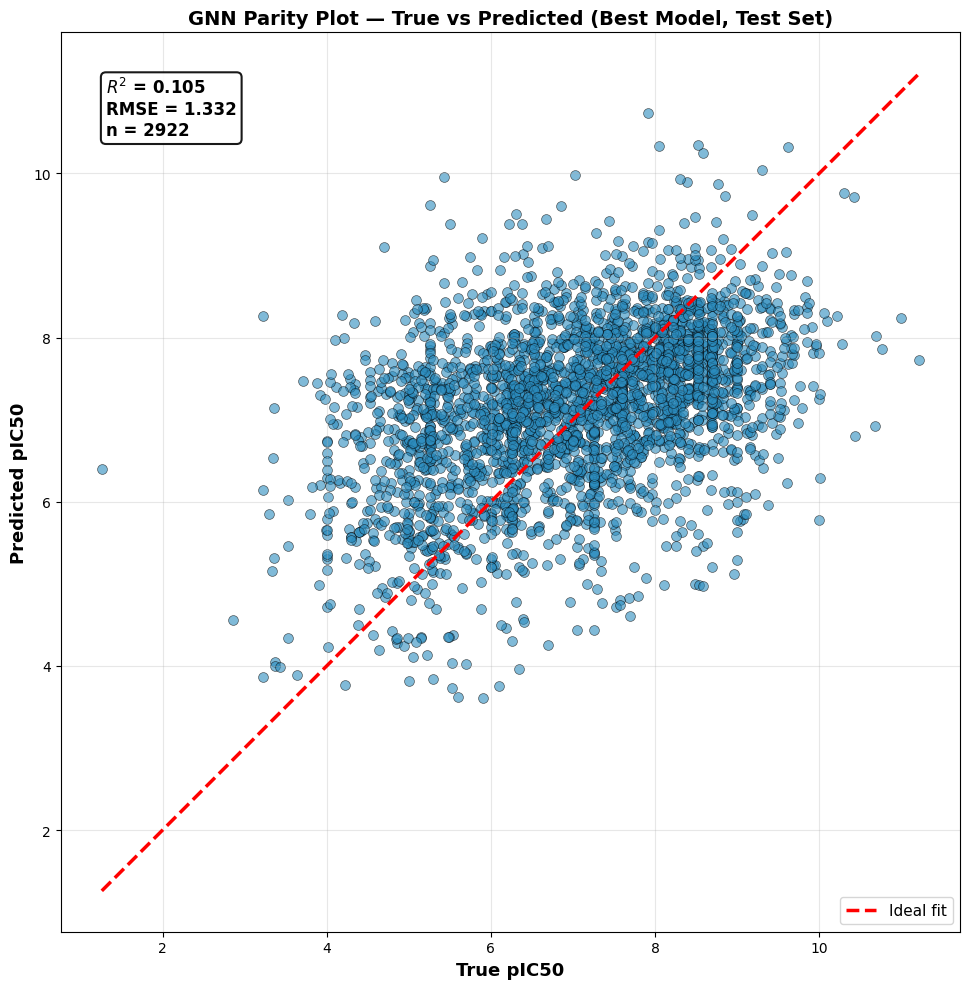

In [6]:
# Evaluation: Load best model and generate parity plot on TEST set
if len(test_graphs) > 0:
    # Load best model
    if best_model_path.exists():
        model.load_state_dict(torch.load(best_model_path, weights_only=False))
        print(f'✓ Loaded best model from {best_model_path}')
    else:
        print('⚠ Best model not found; using current model')
    
    # Determine edge feature dimension
    edge_feat_dim = test_graphs[0].edge_attr.shape[1] if (hasattr(test_graphs[0], 'edge_attr') and test_graphs[0].edge_attr is not None) else 4
    
    model.eval()
    y_test_preds = []
    
    print(f'\nEvaluating on {len(test_graphs)} test graphs...')
    with torch.no_grad():
        for g in test_graphs:
            if hasattr(g, 'x') and g.x is not None:
                x = g.x.float().to(device)
                edge_index = (g.edge_index if g.edge_index is not None else torch.zeros((2, 0), dtype=torch.long)).to(device)
                
                # Handle edge attributes
                if g.edge_attr is not None:
                    edge_attr = g.edge_attr.float().to(device)
                else:
                    n_edges = edge_index.shape[1] if edge_index.shape[1] > 0 else 0
                    edge_attr = torch.randn((n_edges, edge_feat_dim), dtype=torch.float, device=device) * 0.01 + 0.1
                
                # Handle 3D positions
                pos = g.pos.float().to(device) if (hasattr(g, 'pos') and g.pos is not None) else None
                
                # Single-graph batch: all nodes belong to graph 0
                batch = torch.zeros(x.shape[0], dtype=torch.long, device=device)
                global_features = g.global_features.float().to(device) if (hasattr(g, 'global_features') and g.global_features is not None) else None
                fingerprint = g.fingerprint.float().to(device) if (hasattr(g, 'fingerprint') and g.fingerprint is not None) else None
                
                pred = model(x, edge_index, batch, edge_attr=edge_attr, global_features=global_features, pos=pos, fingerprint=fingerprint)
                y_test_preds.append(float(pred.view(-1)[0].item()))
    
    y_test_preds = np.array(y_test_preds)
    
    # Denormalize predictions if targets were normalized during training
    if y_std > 0:
        y_test_preds = y_test_preds * y_std + y_mean
    
    y_true = y_test
    y_pred = y_test_preds
    
    # Compute metrics
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Create parity plot
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(y_true, y_pred, alpha=0.6, s=50, color='#2b8cbe', edgecolors='black', linewidth=0.5)
    
    # Add 45-degree reference line
    mn = min(min(y_true), min(y_pred))
    mx = max(max(y_true), max(y_pred))
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2.5, label='Ideal fit')
    
    ax.set_xlabel('True pIC50', fontsize=13, fontweight='bold')
    ax.set_ylabel('Predicted pIC50', fontsize=13, fontweight='bold')
    ax.set_title('GNN Parity Plot — True vs Predicted (Best Model, Test Set)', fontsize=14, fontweight='bold')
    
    # Annotate metrics
    metrics_text = f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nn = {len(y_true)}'
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=1.5))
    
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    out = OUT / 'gnn_parity_plot.png'
    plt.savefig(out, dpi=300, bbox_inches='tight')
    print(f'\n✓ Parity plot saved to {out}')
    print(f'\n{"="*60}')
    print(f'TEST SET EVALUATION RESULTS (Best Model):')
    print(f'{"="*60}')
    print(f'  R² Score: {r2:.4f}')
    print(f'  RMSE:     {rmse:.4f} pIC50 units')
    print(f'  N Test:   {len(y_true)} molecules')
    print(f'{"="*60}')
else:
    print('ERROR: No test data for evaluation')

In [7]:
# ===== UTILITY: Convert Predicted Graphs Back to SMILES =====

def graph_to_smiles(graph_data):
    """
    Converts a PyG graph back to a SMILES string.
    Handles both the legacy atomic-number layout and the newer
    one-hot atom-type layout, and ignores the edge-distance feature.
    """
    from rdkit import Chem

    atom_symbols = ['C', 'N', 'O', 'F', 'S', 'Cl']
    bond_types = [
        Chem.rdchem.BondType.SINGLE,
        Chem.rdchem.BondType.DOUBLE,
        Chem.rdchem.BondType.TRIPLE,
        Chem.rdchem.BondType.AROMATIC,
    ]

    try:
        mol = Chem.RWMol()

        x = graph_data.x.detach().cpu().numpy() if hasattr(graph_data.x, 'detach') else graph_data.x
        if x is None or len(x) == 0:
            return None

        node_dim = x.shape[1] if getattr(x, 'ndim', 0) == 2 else 0
        atom_type_dim = max(node_dim - 2, 0)
        has_one_hot_atom_types = atom_type_dim > 0 and len(atom_symbols) >= atom_type_dim

        for node_features in x:
            atom = None

            if has_one_hot_atom_types:
                atom_type_slice = np.asarray(node_features[:atom_type_dim], dtype=float)
                if atom_type_slice.size and np.all(np.isfinite(atom_type_slice)):
                    one_hot_like = np.all((atom_type_slice >= -1e-6) & (atom_type_slice <= 1.0 + 1e-6)) and np.isclose(atom_type_slice.sum(), 1.0, atol=1e-3)
                    if one_hot_like:
                        atom_idx = int(np.argmax(atom_type_slice))
                        if atom_idx < len(atom_symbols):
                            atom = Chem.Atom(atom_symbols[atom_idx])

            if atom is None:
                raw_atomic_num = int(round(float(node_features[0])))
                if raw_atomic_num > 0:
                    atom = Chem.Atom(raw_atomic_num)

            if atom is None:
                return None

            mol.AddAtom(atom)

        edge_index = graph_data.edge_index.detach().cpu().numpy() if hasattr(graph_data.edge_index, 'detach') else graph_data.edge_index
        edge_attr = graph_data.edge_attr.detach().cpu().numpy() if hasattr(graph_data.edge_attr, 'detach') else graph_data.edge_attr
        if edge_index is not None and edge_index.size > 0:
            added_bonds = set()
            num_edges = edge_index.shape[1] if edge_index.shape[0] == 2 else edge_index.shape[0]

            for edge_idx in range(num_edges):
                if edge_index.shape[0] == 2:
                    start = int(edge_index[0, edge_idx])
                    end = int(edge_index[1, edge_idx])
                else:
                    start = int(edge_index[edge_idx, 0])
                    end = int(edge_index[edge_idx, 1])

                bond_pair = tuple(sorted((start, end)))
                if start == end or bond_pair in added_bonds:
                    continue

                bond_type = Chem.rdchem.BondType.SINGLE
                if edge_attr is not None and edge_idx < len(edge_attr):
                    bond_slice = np.asarray(edge_attr[edge_idx], dtype=float)
                    if bond_slice.size >= 4:
                        bond_type_idx = int(np.argmax(bond_slice[:4]))
                        bond_type = bond_types[bond_type_idx]

                try:
                    mol.AddBond(bond_pair[0], bond_pair[1], bond_type)
                    added_bonds.add(bond_pair)
                except Exception as bond_error:
                    print(f'Bond reconstruction error for {bond_pair}: {bond_error}')

        mol = mol.GetMol()
        try:
            Chem.SanitizeMol(mol)
        except Exception as sanitize_error:
            print(f'SanitizeMol failed: {sanitize_error}')
            try:
                return Chem.MolToSmiles(mol, canonical=False)
            except Exception as fallback_error:
                print(f'Fallback MolToSmiles failed: {fallback_error}')
                return None

        try:
            return Chem.MolToSmiles(mol, canonical=True)
        except Exception as smiles_error:
            print(f'MolToSmiles failed: {smiles_error}')
            return None

    except Exception as e:
        print(f'graph_to_smiles failed: {e}')
        return None

print('✓ Graph-to-SMILES conversion function ready')


✓ Graph-to-SMILES conversion function ready


In [8]:
# Diagnostic: reconstruct a single real test graph
if len(test_graphs) > 0:
    sample_graph = test_graphs[0]
    print('Testing test_graphs[0]')
    print(f'  x shape: {tuple(sample_graph.x.shape) if hasattr(sample_graph, "x") and sample_graph.x is not None else None}')
    print(f'  edge_index shape: {tuple(sample_graph.edge_index.shape) if hasattr(sample_graph, "edge_index") and sample_graph.edge_index is not None else None}')
    print(f'  edge_attr shape: {tuple(sample_graph.edge_attr.shape) if hasattr(sample_graph, "edge_attr") and sample_graph.edge_attr is not None else None}')
    try:
        smiles = graph_to_smiles(sample_graph)
        print(f'Reconstructed SMILES: {smiles}')
    except Exception as error:
        print(f'ERROR during reconstruction: {type(error).__name__}: {error}')
else:
    print('ERROR: test_graphs is empty')

Testing test_graphs[0]
  x shape: (32, 8)
  edge_index shape: (2, 72)
  edge_attr shape: (72, 5)
Reconstructed SMILES: O=C1COc2cc3ncnc(Nc4cccc(F)c4)c3cc2N1CCCN1CCCCC1


✓ Saved training diagnostics: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\training_diagnostics.png


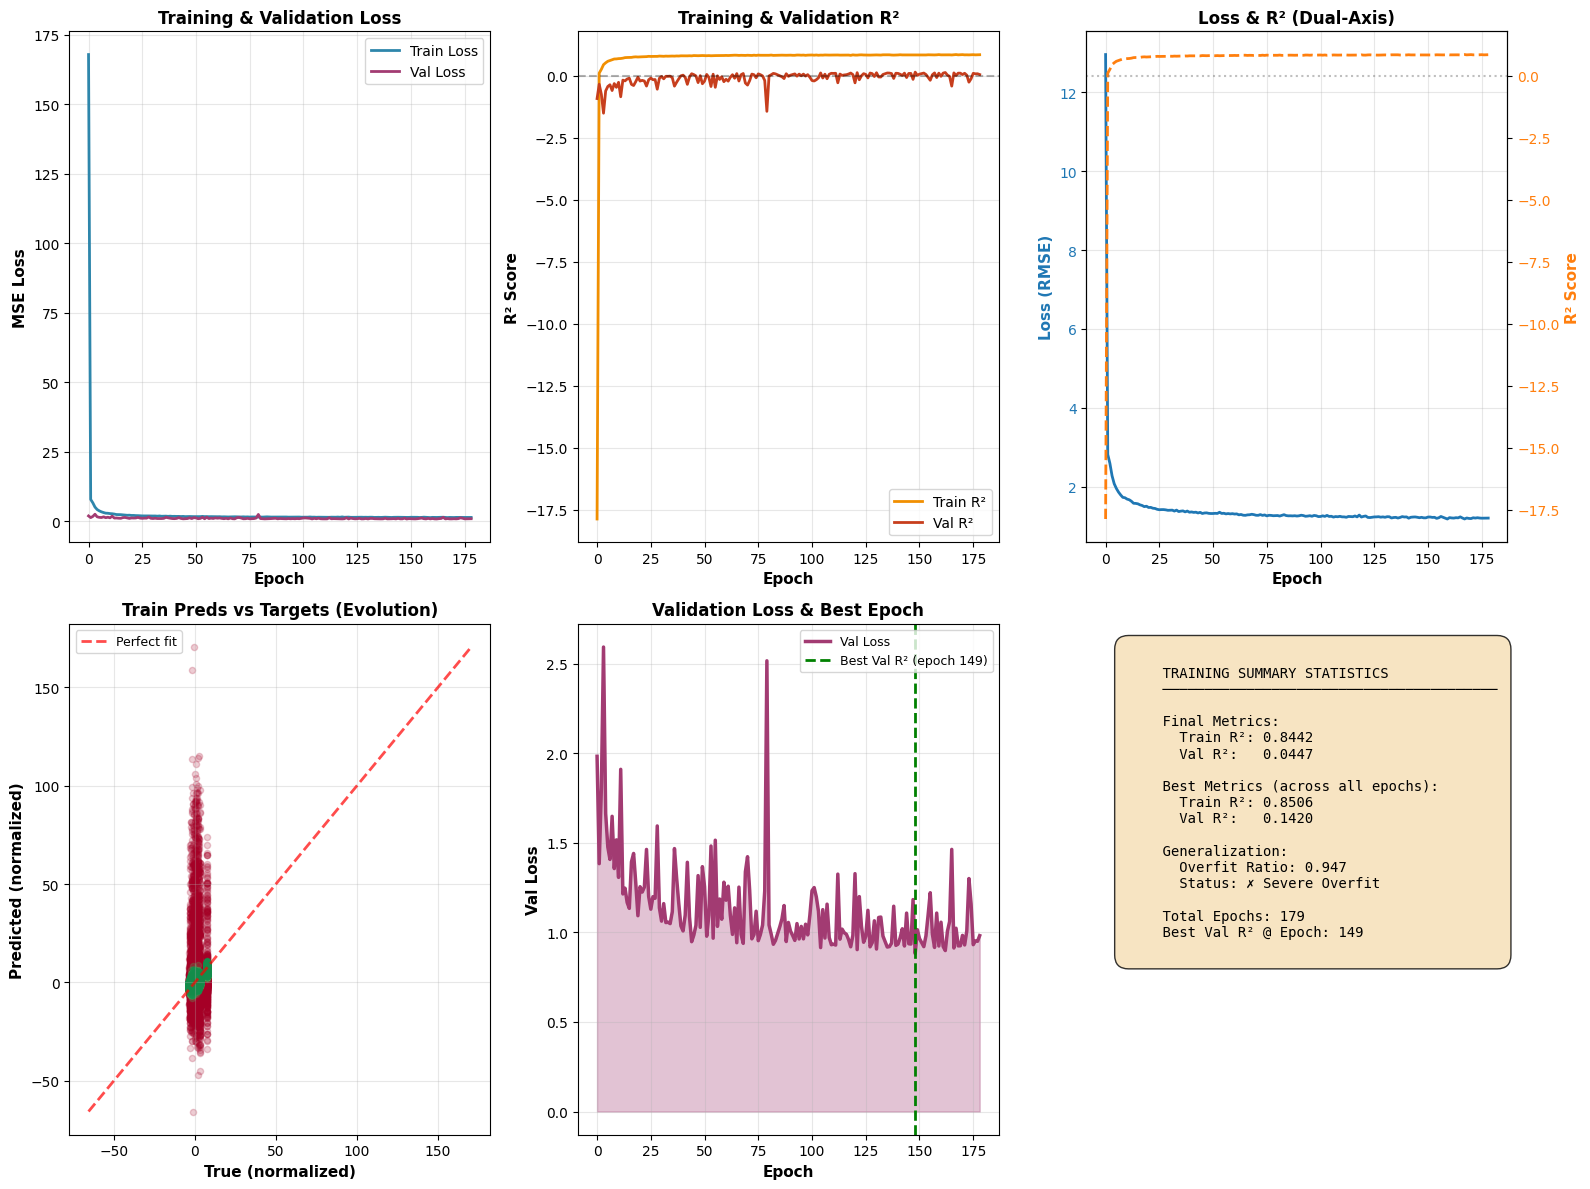


📊 Training Summary:
  Final Train R²: 0.8442
  Final Val R²:   0.0447
  Best Val R² achieved at epoch 149: 0.1420


In [9]:
# ===== TRAINING VISUALIZATION: Loss, R², and Prediction Curves =====

if len(train_losses) > 0:
    import seaborn as sns
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Loss curve (train vs val)
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(train_losses, label='Train Loss', linewidth=2, color='#2E86AB')
    ax1.plot(val_losses, label='Val Loss', linewidth=2, color='#A23B72')
    ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax1.set_ylabel('MSE Loss', fontsize=11, fontweight='bold')
    ax1.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 2. R² curve (train vs val)
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(train_r2_list, label='Train R²', linewidth=2, color='#F18F01')
    ax2.plot(val_r2_list, label='Val R²', linewidth=2, color='#C73E1D')
    ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
    ax2.set_title('Training & Validation R²', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # 3. Loss + R² dual-axis (from Medium article pattern)
    ax3 = plt.subplot(2, 3, 3)
    color_loss = 'tab:blue'
    ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Loss (RMSE)', color=color_loss, fontsize=11, fontweight='bold')
    rmse_train = np.sqrt(np.array(train_losses))
    ax3.plot(rmse_train, color=color_loss, linewidth=2, label='Train RMSE')
    ax3.tick_params(axis='y', labelcolor=color_loss)
    ax3.grid(True, alpha=0.3)
    
    ax3_twin = ax3.twinx()
    color_r2 = 'tab:orange'
    ax3_twin.set_ylabel('R² Score', color=color_r2, fontsize=11, fontweight='bold')
    ax3_twin.plot(train_r2_list, color=color_r2, linewidth=2, label='Train R²', linestyle='--')
    ax3_twin.tick_params(axis='y', labelcolor=color_r2)
    ax3_twin.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    
    ax3.set_title('Loss & R² (Dual-Axis)', fontsize=12, fontweight='bold')
    
    # 4. Train predictions vs targets (first 100 epochs if available)
    ax4 = plt.subplot(2, 3, 4)
    n_plots = min(20, len(train_preds_history))
    for i in range(n_plots):
        epoch_idx = int(len(train_preds_history) * (i / n_plots))
        pred = train_preds_history[epoch_idx]
        targ = train_targets_history[epoch_idx]
        r2_epoch = train_r2_list[epoch_idx]
        alpha = 0.2 + 0.6 * (i / n_plots)  # Gradually increase alpha
        color_value = plt.cm.RdYlGn((r2_epoch + 1) / 2)
        ax4.scatter(targ, pred, alpha=alpha, s=20, color=color_value)
    
    # Add perfect prediction line
    mn = min(min([t.min() for t in train_targets_history]), min([p.min() for p in train_preds_history]))
    mx = max(max([t.max() for t in train_targets_history]), max([p.max() for p in train_preds_history]))
    ax4.plot([mn, mx], [mn, mx], 'r--', linewidth=2, alpha=0.7, label='Perfect fit')
    ax4.set_xlabel('True (normalized)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Predicted (normalized)', fontsize=11, fontweight='bold')
    ax4.set_title('Train Preds vs Targets (Evolution)', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # 5. Early stops and Best epoch identification
    ax5 = plt.subplot(2, 3, 5)
    best_val_r2_idx = np.argmax(val_r2_list)
    ax5.fill_between(range(len(val_losses)), val_losses, alpha=0.3, color='#A23B72')
    ax5.plot(val_losses, linewidth=2.5, color='#A23B72', label='Val Loss')
    ax5.axvline(x=best_val_r2_idx, color='green', linestyle='--', linewidth=2, label=f'Best Val R² (epoch {best_val_r2_idx+1})')
    ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Val Loss', fontsize=11, fontweight='bold')
    ax5.set_title('Validation Loss & Best Epoch', fontsize=12, fontweight='bold')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    # 6. Summary metrics box
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    final_train_r2 = train_r2_list[-1]
    final_val_r2 = val_r2_list[-1]
    best_train_r2 = max(train_r2_list)
    best_val_r2 = max(val_r2_list)
    overfit_ratio = (final_train_r2 - final_val_r2) / max(abs(final_train_r2), 0.01)
    
    summary_text = f"""
    TRAINING SUMMARY STATISTICS
    {'─' * 40}
    
    Final Metrics:
      Train R²: {final_train_r2:.4f}
      Val R²:   {final_val_r2:.4f}
      
    Best Metrics (across all epochs):
      Train R²: {best_train_r2:.4f}
      Val R²:   {best_val_r2:.4f}
      
    Generalization:
      Overfit Ratio: {overfit_ratio:.3f}
      Status: {'✓ Good' if abs(overfit_ratio) < 0.3 else '⚠ Possible Overfit' if abs(overfit_ratio) < 0.5 else '✗ Severe Overfit'}
      
    Total Epochs: {len(train_losses)}
    Best Val R² @ Epoch: {best_val_r2_idx + 1}
    """
    
    ax6.text(0.1, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, pad=1))
    
    plt.tight_layout()
    training_viz_out = OUT / 'training_diagnostics.png'
    plt.savefig(training_viz_out, dpi=300, bbox_inches='tight')
    print(f'✓ Saved training diagnostics: {training_viz_out}')
    plt.show()
    
    print(f'\n📊 Training Summary:')
    print(f'  Final Train R²: {final_train_r2:.4f}')
    print(f'  Final Val R²:   {final_val_r2:.4f}')
    print(f'  Best Val R² achieved at epoch {best_val_r2_idx + 1}: {best_val_r2:.4f}')
else:
    print('⚠ No training history available for visualization')


In [10]:
# ===== TEST VALIDATION: Reconstruct SMILES & Check Chemical Validity =====

if len(test_graphs) > 0:
    print('\n' + '=' * 70)
    print('SMILES RECONSTRUCTION & CHEMICAL VALIDITY CHECK')
    print('=' * 70)
    
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen
    
    valid_smiles_list = []
    invalid_count = 0
    
    print(f'\nAttempting to reconstruct SMILES from {len(test_graphs)} test graphs...\n')
    
    for i, graph in enumerate(test_graphs):
        smiles_reconstructed = graph_to_smiles(graph)
        if smiles_reconstructed is None:
            invalid_count += 1
            continue
        mol_check = Chem.MolFromSmiles(smiles_reconstructed)
        if mol_check is None:
            invalid_count += 1
            continue
        mw = Descriptors.MolWt(mol_check)
        logp = Crippen.MolLogP(mol_check)
        valid_smiles_list.append(smiles_reconstructed)
    
    # Summary
    if len(test_graphs) > 0:
        total_checked = len(test_graphs)
        valid_count = total_checked - invalid_count
        validity_rate = 100 * valid_count / total_checked
        
        print(f'\n{"─" * 70}')
        print(f'Reconstruction Results (all test graphs):')
        print(f'  Valid:   {valid_count} ({validity_rate:.1f}%)')
        print(f'  Invalid: {invalid_count} ({100 - validity_rate:.1f}%)')
        print(f'{"─" * 70}')
else:
    print('⚠ No test graphs available for SMILES reconstruction')



SMILES RECONSTRUCTION & CHEMICAL VALIDITY CHECK

Attempting to reconstruct SMILES from 2922 test graphs...

SanitizeMol failed: Explicit valence for atom # 25 N, 4, is greater than permitted
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 15
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 34
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 16 17 18 21 22
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 29 30
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14 15 32
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23 24 25
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 1 2 3 12 13 14 15 16 17 18 19 20 21
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 12 13 14 18 19
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 4 5 6 20 28
SanitizeMol failed: 

[13:40:01] Explicit valence for atom # 25 N, 4, is greater than permitted
[13:40:01] Explicit valence for atom # 30 N, 4, is greater than permitted
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 15
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 15
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 34
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 34
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 16 17 18 21 22
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 16 17 18 21 22
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 29 30
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 29 30
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14 15 32
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14 15 32
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23 24 25
[13:40:01] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22
[13:40:01] Can't kekulize mo

SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 32 33 37
SanitizeMol failed: Explicit valence for atom # 2 N, 4, is greater than permitted
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 19
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 13
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 20 21 22 23 24 25 26 27 28
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 26
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 12 13 14 32 33 34 35 36 37
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 14 15 16 17 18 19 20 21 22 23 25
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10 16 17 18 19
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 10 11 25 26 27 28 29 30 35
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 18 19 20 21 22 23 24 25 26
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 18 19 20 21 22 23 

[13:40:02] Can't kekulize mol.  Unkekulized atoms: 31 32 33 34 35 36 37
[13:40:02] Can't kekulize mol.  Unkekulized atoms: 31 32 33 34 35 36 37
[13:40:02] Explicit valence for atom # 20 N, 4, is greater than permitted
[13:40:02] Explicit valence for atom # 22 N, 4, is greater than permitted
[13:40:02] Explicit valence for atom # 27 N, 4, is greater than permitted
[13:40:02] Explicit valence for atom # 27 N, 4, is greater than permitted
[13:40:02] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14 15 24
[13:40:02] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14 15 24
[13:40:02] Explicit valence for atom # 20 N, 4, is greater than permitted
[13:40:02] Explicit valence for atom # 5 N, 4, is greater than permitted
[13:40:02] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 16 17 18 19
[13:40:02] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 16 17 18 19
[13:40:02] Can't kekulize mol.  Unkekulized atoms: 10 11 12 14 15 16 17 27 28
[13:40:02] Can't kekulize m

SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 31 32 33 34 35 36 37
SanitizeMol failed: Explicit valence for atom # 20 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 27 N, 4, is greater than permitted
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14 15 24
SanitizeMol failed: Explicit valence for atom # 20 N, 4, is greater than permitted
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 16 17 18 19
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 10 11 12 14 15 16 17 27 28
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16 17 18 19 20
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23 24 25 26 27
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 40 41
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 23 26 27 28
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 19


...

[13:40:05] Can't kekulize mol.  Unkekulized atoms: 26 27 28 29 30 31 32 33 34
[13:40:05] Can't kekulize mol.  Unkekulized atoms: 26 27 28 29 30 31 32 33 34
[13:40:05] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 14 16 17 18
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 14 16 17 18
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 16 17 35 36
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 16 17 35 36
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 16 17 18 35
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16 17 34
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 1 2 3 15 16
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 15 16 17 18 19 20 21 22 23
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 15 16 17 18 19 20 21 22 23
[13:40:06] Explicit valence for atom # 38 N, 4, is greater than permitted
[13:40:06] Explicit valenc

SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 26 27 28 29 30 31 32 33 34
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 14 16 17 18
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 16 17 35 36
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 16 17 18 35
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 15 16 17 18 19 20 21 22 23
SanitizeMol failed: Explicit valence for atom # 38 N, 4, is greater than permitted
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 1 2 3 12 13 14 28 29 30
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10 41 42
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 29 30 31 32 33
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 22 23 24 25 26
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 11 12 13 19 20
Saniti

[13:40:06] Can't kekulize mol.  Unkekulized atoms: 11 12 13 21 22 23 24 25 26
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 11 12 13 21 22 23 24 25 26
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 17 18 19 20 21
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 18 19 20 21 22
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23 24 25 26 27
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23 24 25 26 27
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 30 31 35
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 30 31 35
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 16 17
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 34
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16
[13:40:06] Can't kekulize

SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 11 12 13 21 22 23 24 25 26
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 17 18 19 20 21
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23 24 25 26 27
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 30 31 35
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 16 17 18 21 22
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14 15 16
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 9 10 1

[13:40:06] Explicit valence for atom # 21 N, 4, is greater than permitted
[13:40:06] Explicit valence for atom # 21 N, 4, is greater than permitted
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 13 14 15 16 17
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 13 14 15 16 17
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14 15 24
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 12 13 14 15 24
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 29 30 31 32 33 34 35 36 37
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 29 30 31 32 33 34 35 36 37
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 4 5 6 26 34
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 4 5 6 26 34
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 10 11 25 26 27 28 29 30 36
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 10 11 25 26 27 28 29 30 36
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[13:40:06] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 